# Causal Discovery and Causal Feature Selection for Robust Prediction

This tutorial walks through the key ideas and algorithms at the intersection of causal inference and robust machine learning.
The tutorial is structured as follows:

1. **Pairwise causal discovery** — can we tell which variable causes which, from observational data alone?
2. **Multivariate causal discovery** — recovering the full causal graph over many variables
3. **Multivariate causal feature selection** — finding the Markov Blanket of a target variable
4. **CFS for robust prediction** — why causal parents are more stable predictors than correlated features
5. **Invariant Causal Predictors** — a principled method to find invariant features across environments

In [1]:
import os
if not os.path.exists('zh03-causal-discovery-robust-predictions'):
    !git clone https://github.com/WinterSchool2026/zh03-causal-discovery-robust-predictions.git
import sys
# sys.path.insert(0, 'zh03-causal-discovery-robust-predictions')

In [2]:
# Standard library
import time

# Core libraries
import numpy as np
import pandas as pd

# SciPy / stats
from scipy.stats import pearsonr
from numpy.linalg import lstsq

# causal-learn
from causallearn.search.ConstraintBased.PC import pc
from causallearn.search.ScoreBased.GES import ges
from causallearn.utils.cit import fisherz
from src.ci_test import *
from src.ci_test import ci_table


# Local project modules
from src.generate_scm import *

# Reproducibility
np.random.seed(2)


/home/homer/anaconda3/envs/attribution_chanllenge/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## Section 1.5 — Markov Equivalence Classes

Consider three variables $X0, X1, X2$ and the following three DAGs:

```
(1)  $X_0$ → $X_1$ → $X_2$        (chain)
(2)  $X_0$ ← $X_1$ → $X_2$        (fork / common cause)
(3)  $X_0$ → $X_1$ ← $X_2$        (collider / v-structure)
```

In DAGs (1) and (2), $X_0$ and $X_2$ are **marginally dependent** but **conditionally independent given $X_1$** — written X0 ⊥ X2 | X1. In DAG (3), $X_0$ and $X_2$ are **marginally independent** but become **dependent when conditioning on $X_1$** (the collider).

This distinction is testable from data. But crucially, **(1) and (2) are indistinguishable from observational data alone**: they encode exactly the same conditional independencies. No statistical test — without further assumptions — can tell them apart.

### 1.5.2 Markov Equivalence Classes (MEC)

Two DAGs are **Markov equivalent** if they have the same skeleton (undirected edges) and the same **v-structures** (patterns $X → Z ← Y$ where $X$ and $Y$ are not adjacent). 

The set of all Markov-equivalent DAGs forms the **Markov Equivalence Class (MEC)**. Constraint-based algorithms can recover only the MEC. Their output is a **CPDAG** (Completed Partially Directed Acyclic Graph): edges that point the same way across all DAGs in the MEC appear as arrows; edges that could go either way appear as undirected lines.

### 1.5.3 What PC orients and what it leaves undirected

PC proceeds in two phases:

1. **Skeleton recovery**: remove edges wherever a conditional independence is found.
2. **Orientation**: orient v-structures (forced by the data), then propagate via Meek rules without creating new v-structures or cycles.

Edges that cannot be oriented by these rules remain undirected.

True DAGs:


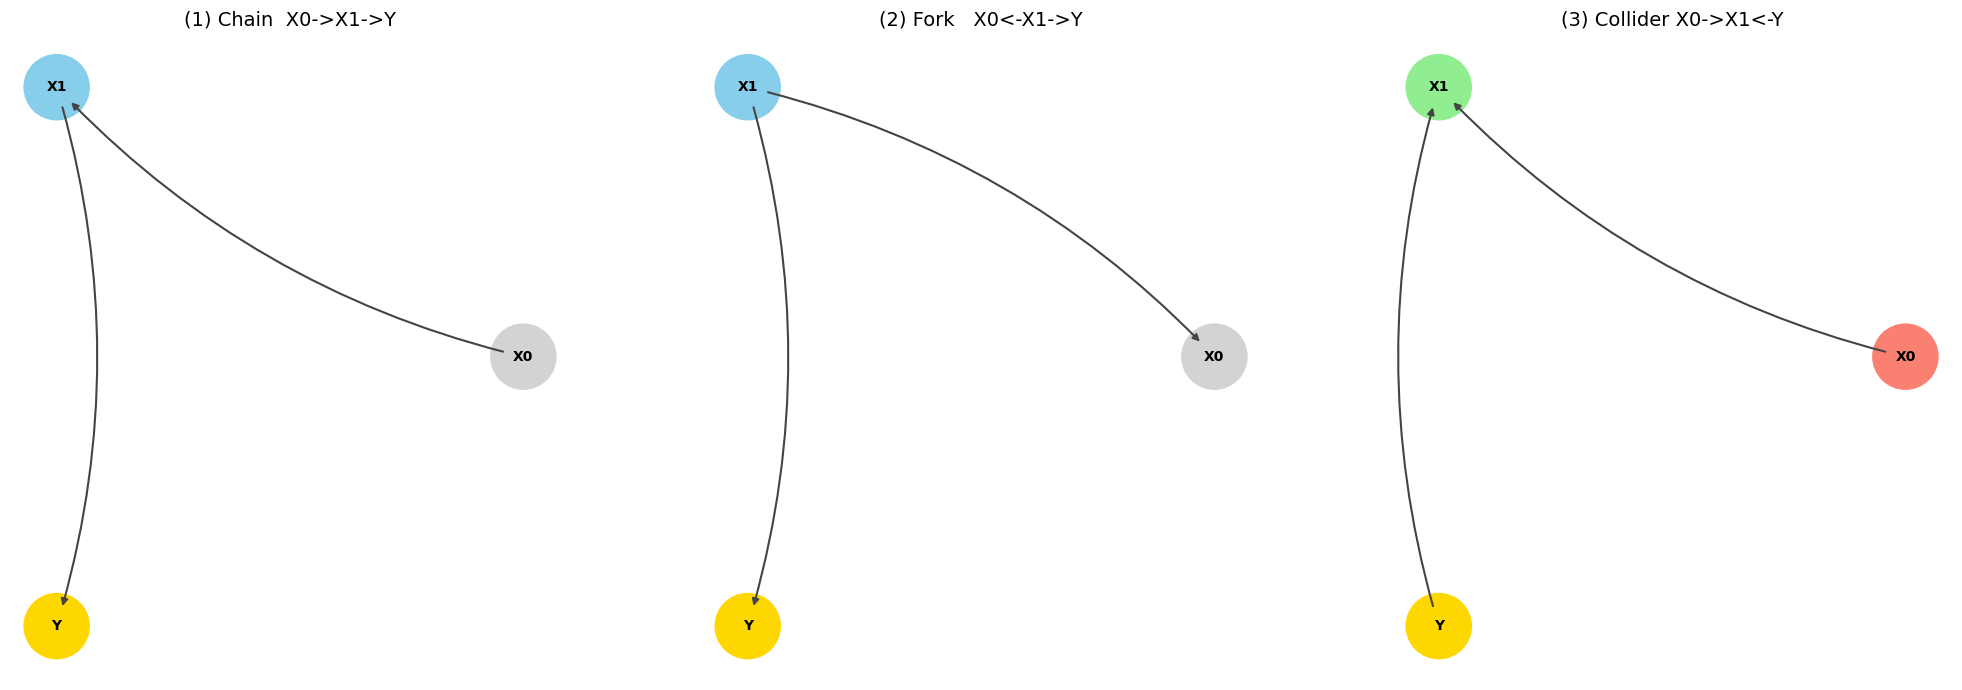

In [3]:

# ----------------------------------------------------------------
# Build three 3-variable SCMs manually via adjacency matrices
# Variables: X0, X1, X2  (d=2, so Y is X2 in the SCM framework)
# ----------------------------------------------------------------
d = 2  # 2 non-target vars + target Y => 3 nodes total

def make_scm_from_adj(A_matrix, seed=13):
    np.random.seed(seed)
    scm = SCMGenerator(d=d)
    scm.fit_from_adjacency(A_matrix, Y_idx=d,
                           noise_type='uniform', is_linear=True)
    return scm

col_names = ['X0', 'X1', 'Y']  # Y plays the role of X2

# (1) Chain:    X0 -> X1 -> Y
A_chain = np.array([[0, 1, 0],
                    [0, 0, 1],
                    [0, 0, 0]], dtype=float)

# (2) Fork:     X0 <- X1 -> Y   (X1 is the common cause)
A_fork  = np.array([[0, 0, 0],
                    [1, 0, 1],
                    [0, 0, 0]], dtype=float)

# (3) Collider: X0 -> X1 <- Y
A_coll  = np.array([[0, 1, 0],
                    [0, 0, 0],
                    [0, 1, 0]], dtype=float)

scm_chain = make_scm_from_adj(A_chain)
scm_fork  = make_scm_from_adj(A_fork)
scm_coll  = make_scm_from_adj(A_coll)

print('True DAGs:')
plot_graphs_from_adj([A_chain, A_fork, A_coll],
                     Y_idx_list=[d, d, d],
                     plot_titles=['(1) Chain  X0->X1->Y',
                                  '(2) Fork   X0<-X1->Y',
                                  '(3) Collider X0->X1<-Y'])


### 1.5.5 Step 1 — Enumerate all pairwise conditional independencies

Let's read the CI structure **directly from the data** using Fisher's z-test.
For each pair of variables $(X, Y)$ we test:

- **Marginal independence**: X ⊥ Y  (no conditioning set)
- **Conditional independence given the third variable**: X ⊥ Y | Z

Collecting all CI statements that hold at α = 0.05 gives us the **empirical CI oracle** that any constraint-based algorithm will implicitly rely on.


In [4]:
n_samples = 2000
data_chain = scm_chain.sample(n_samples=n_samples)
ci_table(data_chain, data_chain.columns)



── Index(['X0', 'X1', 'Y'], dtype='object') ──
Pair          Marginal r       p               Cond on   Partial r       p          
------------------------------------------------------------------------------------
X0 ⊥ X1           -0.996   0.000  ✗ dep              Y      -0.197   0.000  ✗ dep   
X0 ⊥ Y            +0.996   0.000  ✗ dep             X1      +0.002   0.945  ✓ indep 
X1 ⊥ Y            -1.000   0.000  ✗ dep             X0      -0.980   0.000  ✗ dep   


In [5]:
data_fork  = scm_fork.sample(n_samples=n_samples)
ci_table(data_fork,  'Fork    (X0 ← X1 → Y)')



── Fork    (X0 ← X1 → Y) ──
Pair          Marginal r       p               Cond on   Partial r       p          
------------------------------------------------------------------------------------
X0 ⊥ X1           +0.998   0.000  ✗ dep              Y      +0.764   0.000  ✗ dep   
X0 ⊥ Y            -0.995   0.000  ✗ dep             X1      -0.006   0.785  ✓ indep 
X1 ⊥ Y            -0.997   0.000  ✗ dep             X0      -0.639   0.000  ✗ dep   


In [6]:
data_coll  = scm_coll.sample(n_samples=n_samples)
ci_table(data_coll,  'Collider (X0 → X1 ← Y)')


── Collider (X0 → X1 ← Y) ──
Pair          Marginal r       p               Cond on   Partial r       p          
------------------------------------------------------------------------------------
X0 ⊥ X1           -0.627   0.000  ✗ dep              Y      -0.996   0.000  ✗ dep   
X0 ⊥ Y            -0.011   0.631  ✓ indep           X1      +0.993   0.000  ✗ dep   
X1 ⊥ Y            +0.784   0.000  ✗ dep             X0      +0.997   0.000  ✗ dep   


### 1.5.6 Step 2 — Run PC and verify against the CI oracle

Now we let PC do the same work automatically. It will:
1. Test CI statements (same Fisher z-test, same α = 0.05)
2. Remove edges where independence holds → skeleton
3. Orient v-structures, then apply Meek rules → CPDAG

The result should be **exactly consistent** with the CI statements you identified above.


Running PC on all three SCMs (n=2000, α=0.05)...


Depth=1, working on node 2: 100%|██████████| 3/3 [00:00<00:00, 464.25it/s] 


Chain     |  PC (α=0.05): 0.02s


Depth=1, working on node 2: 100%|██████████| 3/3 [00:00<00:00, 375.32it/s] 


Fork      |  PC (α=0.05): 0.02s


Depth=1, working on node 2: 100%|██████████| 3/3 [00:00<00:00, 519.10it/s] 

Collider  |  PC (α=0.05): 0.02s



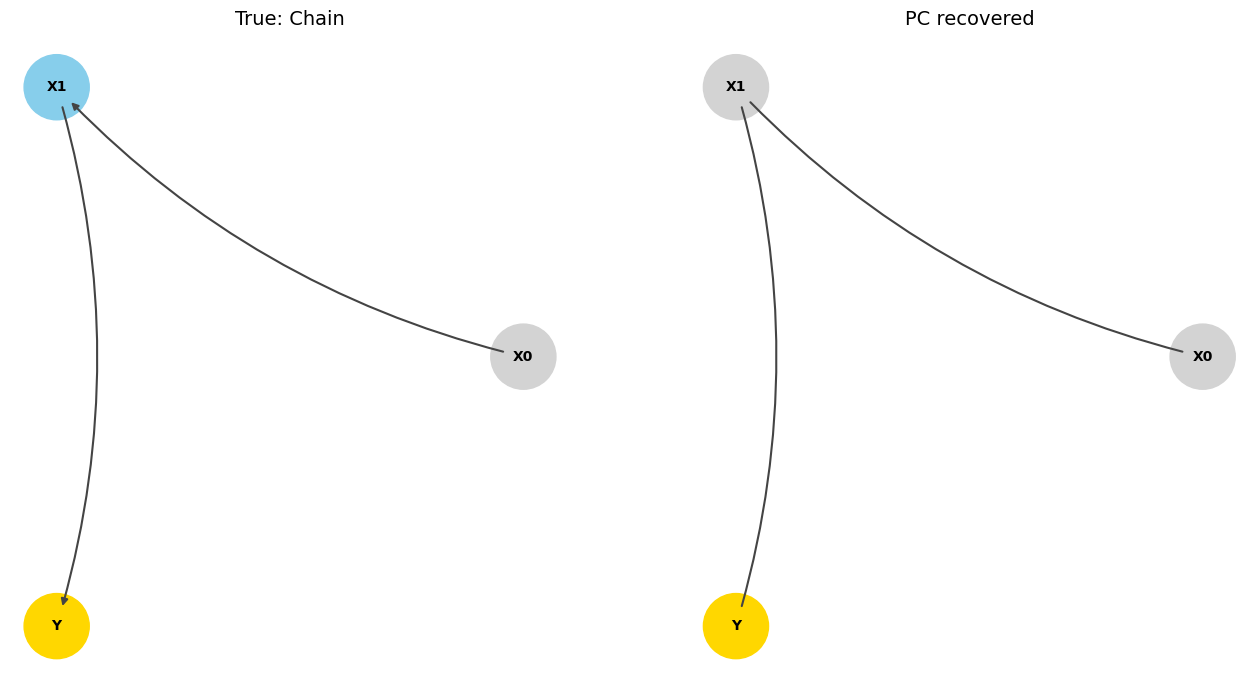

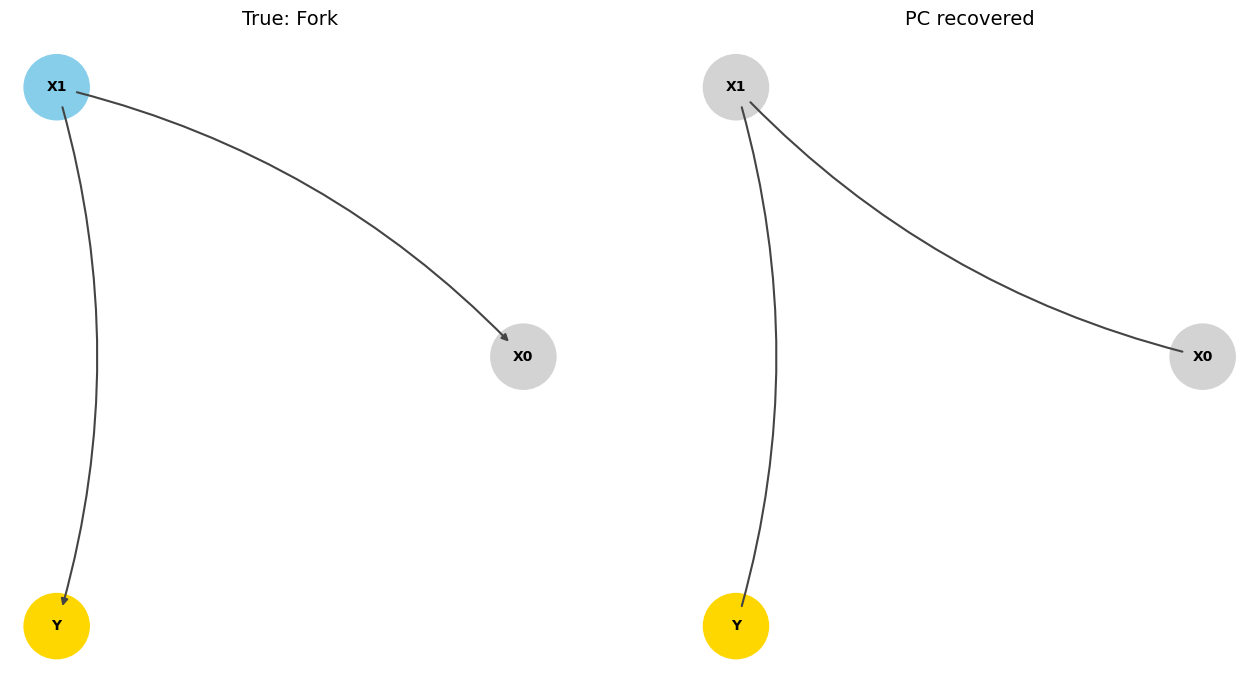

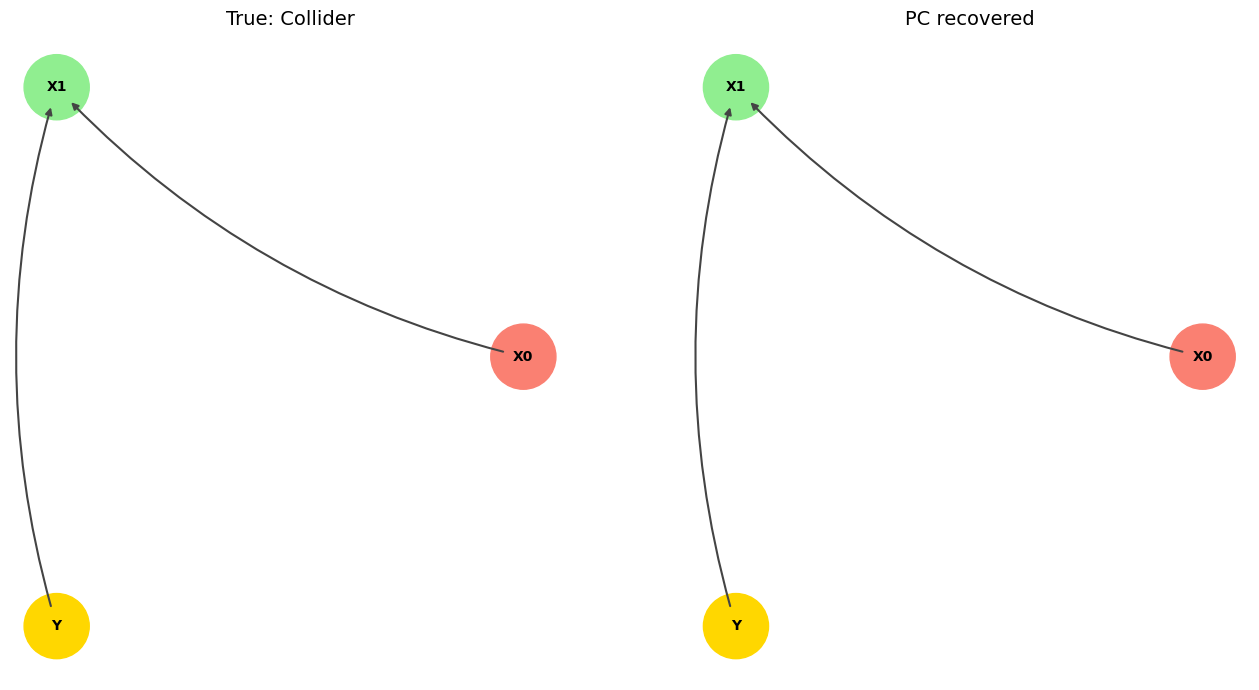

In [7]:
def run_pc(data, col_names, label, alpha=0.05):
    X = data[col_names].values
    t0 = time.time()
    cg = pc(X, alpha=alpha, indep_test=fisherz)
    A = get_adjacency_pc(cg, col_names)
    print(f'{label}  |  PC (α={alpha}): {time.time()-t0:.2f}s')
    return A

print('Running PC on all three SCMs (n=2000, α=0.05)...')
pc_ch = run_pc(data_chain, col_names, 'Chain   ')
pc_fo = run_pc(data_fork,  col_names, 'Fork    ')
pc_co = run_pc(data_coll,  col_names, 'Collider')

print()
plot_graphs_from_adj(
    [A_chain, pc_ch.values],
    Y_idx_list=[d, d],
    plot_titles=['True: Chain', 'PC recovered'])

plot_graphs_from_adj(
    [A_fork, pc_fo.values],
    Y_idx_list=[d, d],
    plot_titles=['True: Fork', 'PC recovered'])

plot_graphs_from_adj(
    [A_coll, pc_co.values],
    Y_idx_list=[d, d],
    plot_titles=['True: Collider', 'PC recovered'])


### 1.5.7 Step 3 — How PC fails: sensitivity to sample size and α

PC's skeleton recovery depends on statistical tests. When samples are scarce or α is poorly chosen:
- **Too few samples** → tests lack power, true edges may survive (false negatives in removal = spurious edges kept) or be incorrectly removed.
- **α too large** → edges are removed too aggressively (over-pruning, missing true edges in skeleton).
- **α too small** → spurious edges survive (under-pruning, false connections).

We test this by varying both axes on the **Collider** SCM (where orientation matters most).


In [8]:
sample_sizes = [50, 200, 500, 2000]
alphas        = [0.001, 0.01, 0.05, 0.20]

# True collider adjacency for comparison
A_true_coll = A_coll  # shape (3,3)

print(f'{"":18}', end='')
for a in alphas:
    print(f'  α={a:<5}', end='')
print()
print('-' * (18 + len(alphas) * 12))

for n in sample_sizes:
    np.random.seed(42)
    df = scm_coll.sample(n_samples=n)
    X_np = df[col_names].values
    row_str = f'n={n:<6} (collider)  '
    for a in alphas:
        cg = pc(X_np, alpha=a, indep_test=fisherz)
        A_rec = get_adjacency_pc(cg, col_names).values
        # Count TP (true edges recovered), FP (spurious edges), FN (missed edges)
        true_edges = int(A_true_coll.sum())
        tp = int(((A_rec > 0) & (A_true_coll > 0)).sum())
        fp = int(((A_rec > 0) & (A_true_coll == 0)).sum())
        fn = int(((A_rec == 0) & (A_true_coll > 0)).sum())
        row_str += f'  TP={tp} FP={fp} FN={fn}'
    print(row_str)

print()
print('TP = true edges recovered  |  FP = spurious edges added  |  FN = true edges missed')


                    α=0.001  α=0.01   α=0.05   α=0.2  
------------------------------------------------------------------


Depth=1, working on node 2: 100%|██████████| 3/3 [00:00<00:00, 456.55it/s] 


n=50     (collider)    TP=2 FP=0 FN=0  TP=2 FP=0 FN=0  TP=2 FP=0 FN=0  TP=2 FP=0 FN=0


Depth=1, working on node 2: 100%|██████████| 3/3 [00:00<00:00, 399.27it/s] 


n=200    (collider)    TP=2 FP=0 FN=0  TP=2 FP=0 FN=0  TP=2 FP=0 FN=0  TP=2 FP=0 FN=0


Depth=1, working on node 2: 100%|██████████| 3/3 [00:00<00:00, 675.85it/s] 


n=500    (collider)    TP=2 FP=0 FN=0  TP=2 FP=0 FN=0  TP=2 FP=0 FN=0  TP=2 FP=0 FN=0


Depth=1, working on node 2: 100%|██████████| 3/3 [00:00<00:00, 442.44it/s] 

n=2000   (collider)    TP=2 FP=0 FN=0  TP=2 FP=0 FN=0  TP=2 FP=0 FN=0  TP=2 FP=0 FN=0

TP = true edges recovered  |  FP = spurious edges added  |  FN = true edges missed


Depth=1, working on node 2: 100%|██████████| 3/3 [00:00<00:00, 416.64it/s] 


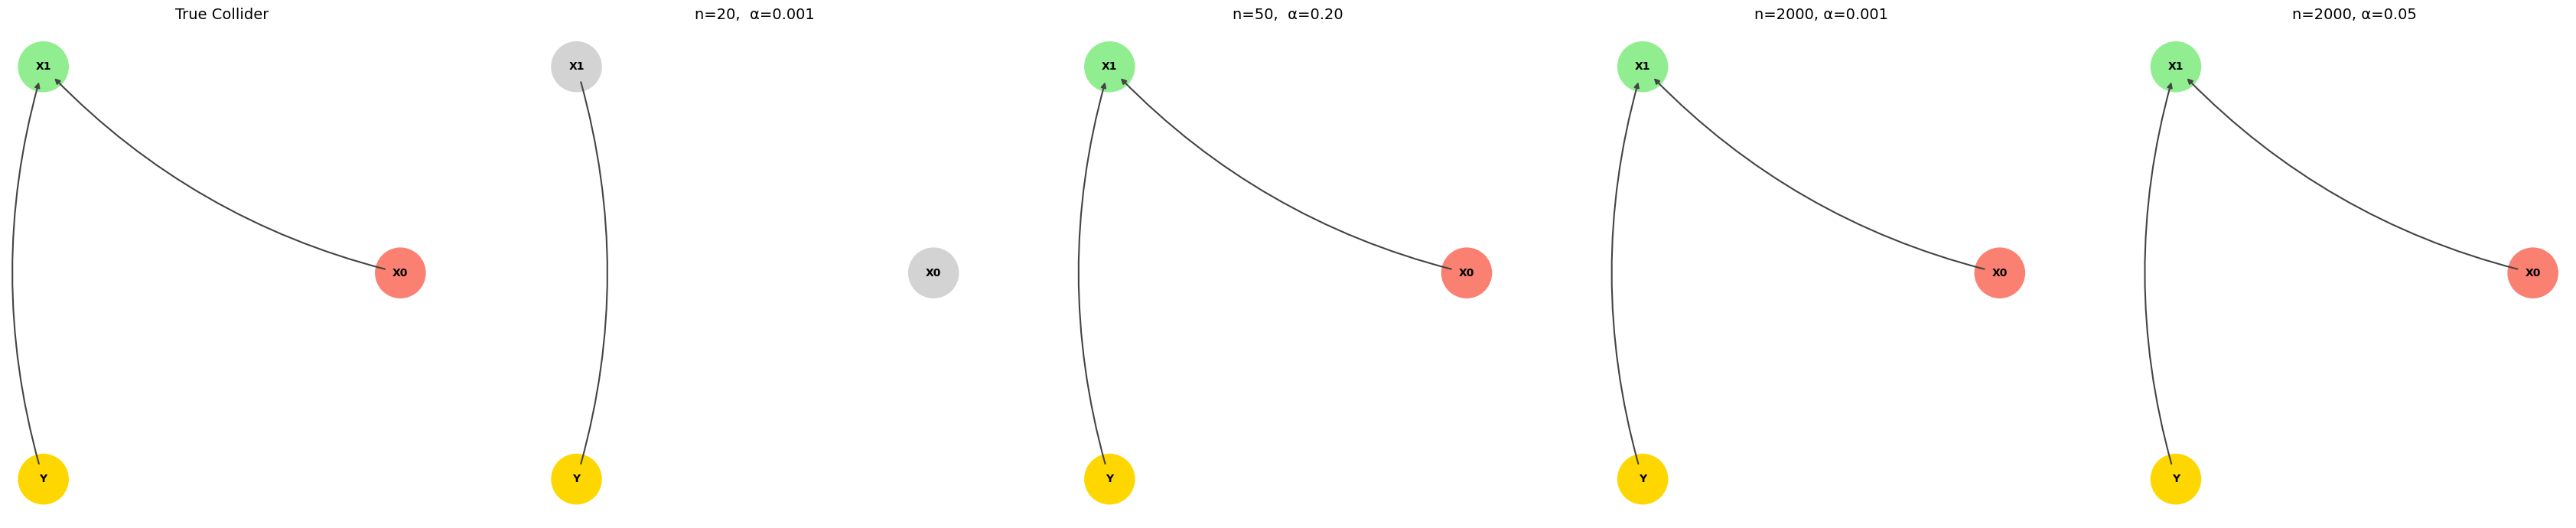

In [9]:
# Visual inspection: show recovered CPDAGs for extreme combinations
configs = [
    (20,   1e-8, 'n=20,  α=0.001'),
    (50,   0.20,  'n=50,  α=0.20'),
    (2000, 0.001, 'n=2000, α=0.001'),
    (2000, 0.05,  'n=2000, α=0.05'),
]

adj_list, titles = [A_coll], ['True Collider']
for n, a, title in configs:
    np.random.seed(42)
    df = scm_coll.sample(n_samples=n)
    cg = pc(df[col_names].values, alpha=a, indep_test=fisherz)
    adj_list.append(get_adjacency_pc(cg, col_names).values)
    titles.append(title)

plot_graphs_from_adj(adj_list, Y_idx_list=[d] * len(adj_list), plot_titles=titles)


### 1.5.8 Step 4 — GES: score-based discovery and scoring strategies

Unlike PC, **GES (Greedy Equivalence Search)** does not perform independence tests. Instead it:
1. Defines a **score** over equivalence classes of DAGs (typically BIC or BDeu).
2. **Forward phase**: greedily inserts edges that most improve the score.
3. **Backward phase**: removes edges whose removal improves the score.

This makes GES:
- **Independent of α** — no threshold to tune.
- Potentially more robust to small samples when the score is well-calibrated.
- But sensitive to the **choice of score function**.

`causal-learn` supports two score functions for continuous data:
- `local_score_BIC` — Bayesian Information Criterion (linear Gaussian assumption).
- `local_score_CV_general` — cross-validation based score, model-agnostic but slower.

We compare both on our three SCMs across different sample sizes.
